# Apple Maps Experience Intel (Public Feedback Evaluation)

This notebook analyzes **public Reddit discussions** about Apple Maps to identify **top user pain points** and translate them into **product-ready priorities**.

**What this is (and is not):**
- ✅ A *product evaluation* exercise (Maps Evaluation-style): metrics → insights → actions
- ✅ Uses only **public** data (no Apple internal data)
- ✅ Designed to be reproducible, readable, and presentation-ready
- ❌ Not a claim about Apple’s internal metrics or user base

## Outputs you can expect
- Theme + post-type tagging (rule-based, transparent)
- Sentiment scoring (VADER baseline)
- Thread-level metrics (pain intensity, consensus, confidence)
- Prioritized list of areas to investigate + representative quotes

## Notebook Sections
1. Setup
2. Data loading
3. Text normalization
4. Theme & post-type labeling
5. Sentiment scoring
6. Thread-level metrics & prioritization
7. Evidence extraction
8. Export artifacts


## 1. Setup

Install/Imports are assumed available via the project's virtual environment.
We keep key constants (like time window) in one place for easy tweaking.


In [1]:
import os
import time
import requests
import pandas as pd
from datetime import datetime, timedelta

In [2]:

# --- CONFIG (edit here) ---------------------------------------------------------
# This notebook is designed to be shareable and reproducible.
# Update paths + parameters here; the rest of the notebook should run end-to-end.

MONTHS_BACK = 8                      # Time window for Reddit collection
SUBREDDITS = ["apple", "applemaps"]  # Subreddits of interest

# Optional limits for quick smoke tests (set to an int). Use None for full pull.
MAX_THREADS_PER_SUBREDDIT = None
MAX_COMMENTS_PER_THREAD = None

# Output folders
OUTPUT_DIR = "../outputs"
DATA_DIR = "../data"
RAW_DIR = f"{DATA_DIR}/raw"
PROCESSED_DIR = f"{DATA_DIR}/processed"

# File names (feel free to rename)
RAW_REDDIT_CSV = f"{RAW_DIR}/reddit_apple_maps_last{MONTHS_BACK}months.csv"
LONG_TABLE_CSV = f"{PROCESSED_DIR}/reddit_maps_long_table.csv"
THREAD_METRICS_CSV = f"{PROCESSED_DIR}/thread_metrics.csv"
EVIDENCE_CSV = f"{PROCESSED_DIR}/evidence_table.csv"

# Confidence buckets (based on number of comments scraped per thread)
# Rationale: more comments = more reliable signal of community reaction.
CONF_HIGH_MIN_COMMENTS = 20
CONF_MED_MIN_COMMENTS = 5

# Pain buckets (decision-ready labels)
# Rationale: thresholds tuned for interpretability, not “scientific truth”.
PAIN_CRITICAL_MIN = 0.35
PAIN_HIGH_MIN = 0.20
PAIN_MED_MIN = 0.10
# -------------------------------------------------------------------------------



### Reproducibility notes

- This project uses **public Reddit threads** (posts + comments) to approximate user pain points.  
- Apple Maps internal teams would have richer telemetry; this notebook demonstrates *evaluation thinking* with public signals.
- All “pain” metrics here are **heuristics** designed for prioritization and discussion, not absolute ground truth.


In [3]:

import os

# Create output folders if they don't exist
for d in [OUTPUT_DIR, DATA_DIR, RAW_DIR, PROCESSED_DIR]:
    os.makedirs(d, exist_ok=True)

print("Folders ready:")
print(" -", OUTPUT_DIR)
print(" -", RAW_DIR)
print(" -", PROCESSED_DIR)


Folders ready:
 - ../outputs
 - ../data/raw
 - ../data/processed



### Environment / requirements

If you want this notebook to run the same way elsewhere, these packages are sufficient:

- `pandas`
- `numpy`
- `matplotlib`
- `tqdm`
- `nltk` (VADER lexicon)
- `praw` (Reddit API) **or** `requests` (scrape fallback)
- `python-dateutil`

Example `requirements.txt` (pin versions as needed):

```
pandas>=2.0
numpy>=1.24
matplotlib>=3.7
tqdm>=4.66
nltk>=3.8
praw>=7.7
python-dateutil>=2.9
```


## 2. Data Loading

Load the raw Reddit export (posts with embedded comment lists).

In [4]:
import pandas as pd
from pathlib import Path

RAW_PATH = Path("../data/raw/apple_maps_reddit.csv")

df_raw = pd.read_csv(RAW_PATH)
df_raw.head()
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   post_id       273 non-null    object 
 1   subreddit     273 non-null    object 
 2   title         273 non-null    object 
 3   selftext      228 non-null    object 
 4   score         273 non-null    int64  
 5   num_comments  273 non-null    int64  
 6   created_utc   273 non-null    float64
 7   created_date  273 non-null    object 
 8   url           273 non-null    object 
 9   comments      273 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 21.5+ KB



### Data quality & filtering

Reddit is noisy. To keep the analysis focused on Apple Maps:

- We create a combined `post_text` (title + selftext). If `selftext` is missing/blank, we fall back to the title.
- We filter to likely Maps-related posts using a lightweight keyword filter (`is_maps_post`).  
  This avoids unrelated Apple discussions (hardware, general iOS news, etc.).
- Comments are stored as a list (per thread) and later normalized into a **long table** so we can:
  - score sentiment per comment
  - compute negative/positive rates
  - extract representative quotes


## 3. Post Text Construction

Create a single `post_text` field (title + selftext). If selftext is missing, we fall back to title.

In [5]:
"""def combine_title_selftext(row):
    title = str(row.get("title") or "").strip()
    body = str(row.get("selftext") or "").strip()
    if title and body and body.lower() != "nan":
        return f"{title}\n\n{body}"
    elif body and body.lower() != "nan":
        return body
    else:
        return title

df = df_raw.copy()
df["post_text"] = df.apply(combine_title_selftext, axis=1)
df.head()"""

'def combine_title_selftext(row):\n    title = str(row.get("title") or "").strip()\n    body = str(row.get("selftext") or "").strip()\n    if title and body and body.lower() != "nan":\n        return f"{title}\n\n{body}"\n    elif body and body.lower() != "nan":\n        return body\n    else:\n        return title\n\ndf = df_raw.copy()\ndf["post_text"] = df.apply(combine_title_selftext, axis=1)\ndf.head()'

In [6]:
import pandas as pd
import ast

df = df_raw.copy()

def combine_title_selftext(row):
    title = str(row.get("title") or "").strip()
    body = str(row.get("selftext") or "").strip()
    if title and body and body.lower() != "nan":
        return f"{title}\n\n{body}"
    elif body and body.lower() != "nan":
        return body
    else:
        return title

df["post_text"] = df.apply(combine_title_selftext, axis=1)

def is_maps_post(text: str) -> bool:
    if not isinstance(text, str):
        return False
    t = text.lower()
    map_keywords = [
        "apple maps",
        "maps app",
        "map app",
        "google maps",
        "waze",
        "tomtom",
        "navigation",
        "navigator",
        "directions",
        "route",
        "routing",
        "turn-by-turn",
        "turn by turn",
        "gps",
    ]
    return any(k in t for k in map_keywords)

df["is_maps_post"] = df["post_text"].apply(is_maps_post)
df[["post_id", "is_maps_post", "post_text"]].head()
df["is_maps_post"].value_counts()


is_maps_post
True     228
False     45
Name: count, dtype: int64

In [7]:
df.head()

,post_id,subreddit,title,selftext,score,num_comments,created_utc,created_date,url,comments,post_text,is_maps_post
0,1pqiqvw,apple,Apple Quietly Discontinued Flyover City Tours ...,NaN,933,83,1.766143e+09,2025-12-19 05:24:28,https://www.reddit.com/r/apple/comments/1pqiqv...,"[""I would rather have the ability to drive a r...",Apple Quietly Discontinued Flyover City Tours ...,True
1,1pgh00h,apple,Made an affordable app to add alarms to remind...,I made this app Cannot Ignore because now in i...,5,30,1.765110e+09,2025-12-07 06:16:43,https://www.reddit.com/r/apple/comments/1pgh00...,['You may have been partially sherlocked as 26...,Made an affordable app to add alarms to remind...,True
2,1paorgu,apple,Apple Developing These 5 New Satellite Feature...,# Summary\n\nThe article describes five new sa...,561,193,1.764526e+09,2025-11-30 11:58:52,https://www.reddit.com/r/apple/comments/1paorg...,['What happened to weather over satellite? I w...,Apple Developing These 5 New Satellite Feature...,True
3,1pakqjh,apple,Built my first Swift app as a professional cro...,Since moving to South Korea (from South Africa...,23,14,1.764516e+09,2025-11-30 09:18:16,https://www.reddit.com/r/apple/comments/1pakqj...,"['Looks great! I especially like the ""Import f...",Built my first Swift app as a professional cro...,False
4,1pa1e9w,apple,The EU says Apple Maps may be big enough to be...,NaN,1003,355,1.764454e+09,2025-11-29 16:14:59,https://www.reddit.com/r/apple/comments/1pa1e9...,"['The EU hasn\'t said anything yet, after the ...",The EU says Apple Maps may be big enough to be...,True


In [8]:
df_maps_posts = df[df["is_maps_post"]].copy()
df_maps_posts.shape
df_maps_posts[["post_id", "post_text"]].head()


,post_id,post_text
0,1pqiqvw,Apple Quietly Discontinued Flyover City Tours ...
1,1pgh00h,Made an affordable app to add alarms to remind...
2,1paorgu,Apple Developing These 5 New Satellite Feature...
4,1pa1e9w,The EU says Apple Maps may be big enough to be...
5,1p8gdql,Apple has notified the EU that its core platfo...


## 4. Normalize to a Long Table (Posts + Comments)

Convert each thread into multiple rows: 1 post row + N comment rows.
This makes sentiment and labeling consistent at the *text item* level.

### Dataframes used (quick map)

- **`df_raw`**: raw thread-level table (1 row per Reddit post/thread) with a `comments` column containing a list of comments (as text).
- **`df_maps_posts`**: `df_raw` filtered to Apple Maps-related threads (based on keyword filter).
- **`df_maps`**: *long* table (multiple rows per thread): one **post** row + many **comment** rows.
- **`df_sent`**: `df_maps` after sentiment scoring.
- **`df_thread_metrics`**: one row per thread with aggregated metrics (pain intensity, consensus, etc.).


In [9]:
rows = []

for i, row in df_maps_posts.iterrows():
    post_id = row["post_id"]
    subreddit = row["subreddit"]
    url = row["url"]
    created_utc = row["created_utc"]
    created_date = row["created_date"]
    score = row["score"]
    num_comments = row["num_comments"]
    post_text = row["post_text"]

    # 1) post row
    rows.append({
        "id": f"post_{post_id}",
        "thread_id": post_id,
        "source": "reddit",
        "subreddit": subreddit,
        "post_or_comment": "post",
        "url": url,
        "created_utc": created_utc,
        "created_date": created_date,
        "score": score,
        "num_comments": num_comments,
        "text": post_text,
    })

    # 2) comment rows
    raw_comments = row.get("comments")
    if pd.isna(raw_comments):
        continue

    try:
        comment_list = ast.literal_eval(raw_comments)
    except Exception:
        continue

    if not isinstance(comment_list, list):
        continue

    for i, c in enumerate(comment_list):
        if not c:
            continue
        rows.append({
            "id": f"comment_{post_id}_{i}",
            "thread_id": post_id,
            "source": "reddit",
            "subreddit": subreddit,
            "post_or_comment": "comment",
            "url": url,
            "created_utc": created_utc,
            "created_date": created_date,
            "score": None,
            "num_comments": None,
            "text": str(c),
        })

df_maps = pd.DataFrame(rows)
df_maps.head()
df_maps["post_or_comment"].value_counts()


post_or_comment
comment    1002
post        228
Name: count, dtype: int64


### Save the normalized long table (posts + comments)

This is the core analysis table used for sentiment, theme classification, and evidence extraction.


In [10]:

# Save long table for reproducibility
df_maps.to_csv(LONG_TABLE_CSV, index=False)
print("Saved long table:", LONG_TABLE_CSV)
print("Shape:", df_maps.shape)


Saved long table: ../data/processed/reddit_maps_long_table.csv
Shape: (1230, 11)


In [11]:
df_maps.columns

Index(['id', 'thread_id', 'source', 'subreddit', 'post_or_comment', 'url',
       'created_utc', 'created_date', 'score', 'num_comments', 'text'],
      dtype='object')

In [12]:
df_maps.head()

,id,thread_id,source,subreddit,post_or_comment,url,created_utc,created_date,score,num_comments,text
0,post_1pqiqvw,1pqiqvw,reddit,apple,post,https://www.reddit.com/r/apple/comments/1pqiqv...,1.766143e+09,2025-12-19 05:24:28,933.0,83.0,Apple Quietly Discontinued Flyover City Tours ...
1,comment_1pqiqvw_0,1pqiqvw,reddit,apple,comment,https://www.reddit.com/r/apple/comments/1pqiqv...,1.766143e+09,2025-12-19 05:24:28,NaN,NaN,I would rather have the ability to drive a rou...
2,comment_1pqiqvw_1,1pqiqvw,reddit,apple,comment,https://www.reddit.com/r/apple/comments/1pqiqv...,1.766143e+09,2025-12-19 05:24:28,NaN,NaN,&gt;Apple Maps no longer offers a Flyover feat...
3,comment_1pqiqvw_2,1pqiqvw,reddit,apple,comment,https://www.reddit.com/r/apple/comments/1pqiqv...,1.766143e+09,2025-12-19 05:24:28,NaN,NaN,I liked the idea but it was painfully slow. I ...
4,comment_1pqiqvw_3,1pqiqvw,reddit,apple,comment,https://www.reddit.com/r/apple/comments/1pqiqv...,1.766143e+09,2025-12-19 05:24:28,NaN,NaN,I've noticed a while ago that the feature was ...


In [13]:
df_maps.columns.tolist()


['id',
 'thread_id',
 'source',
 'subreddit',
 'post_or_comment',
 'url',
 'created_utc',
 'created_date',
 'score',
 'num_comments',
 'text']

In [14]:
"""keep_cols = [
    "thread_id",
    "subreddit",
    "post_or_comment",
    "created_utc",
    "created_date",
    "url",
    "score",
    "num_comments",
    "text",
]

df_maps = df_maps[keep_cols].copy()
df_maps.head()
df_maps.columns.tolist()"""



'keep_cols = [\n    "thread_id",\n    "subreddit",\n    "post_or_comment",\n    "created_utc",\n    "created_date",\n    "url",\n    "score",\n    "num_comments",\n    "text",\n]\n\ndf_maps = df_maps[keep_cols].copy()\ndf_maps.head()\ndf_maps.columns.tolist()'

In [15]:
df_maps.head()

,id,thread_id,source,subreddit,post_or_comment,url,created_utc,created_date,score,num_comments,text
0,post_1pqiqvw,1pqiqvw,reddit,apple,post,https://www.reddit.com/r/apple/comments/1pqiqv...,1.766143e+09,2025-12-19 05:24:28,933.0,83.0,Apple Quietly Discontinued Flyover City Tours ...
1,comment_1pqiqvw_0,1pqiqvw,reddit,apple,comment,https://www.reddit.com/r/apple/comments/1pqiqv...,1.766143e+09,2025-12-19 05:24:28,NaN,NaN,I would rather have the ability to drive a rou...
2,comment_1pqiqvw_1,1pqiqvw,reddit,apple,comment,https://www.reddit.com/r/apple/comments/1pqiqv...,1.766143e+09,2025-12-19 05:24:28,NaN,NaN,&gt;Apple Maps no longer offers a Flyover feat...
3,comment_1pqiqvw_2,1pqiqvw,reddit,apple,comment,https://www.reddit.com/r/apple/comments/1pqiqv...,1.766143e+09,2025-12-19 05:24:28,NaN,NaN,I liked the idea but it was painfully slow. I ...
4,comment_1pqiqvw_3,1pqiqvw,reddit,apple,comment,https://www.reddit.com/r/apple/comments/1pqiqv...,1.766143e+09,2025-12-19 05:24:28,NaN,NaN,I've noticed a while ago that the feature was ...


### Cleaning

In [16]:
import re

def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    t = s.lower()
    t = t.replace("&gt;", ">").replace("&lt;", "<").replace("&amp;", "&")
    t = re.sub(r"http\S+|www\.\S+", "", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

df_maps["text_clean"] = df_maps["text"].fillna("").apply(clean_text)
df_maps[["text", "text_clean"]].head()


,text,text_clean
0,Apple Quietly Discontinued Flyover City Tours ...,apple quietly discontinued flyover city tours ...
1,I would rather have the ability to drive a rou...,i would rather have the ability to drive a rou...
2,&gt;Apple Maps no longer offers a Flyover feat...,>apple maps no longer offers a flyover feature...
3,I liked the idea but it was painfully slow. I ...,i liked the idea but it was painfully slow. i ...
4,I've noticed a while ago that the feature was ...,i've noticed a while ago that the feature was ...


In [17]:
keep_cols = [
    "thread_id",
    "subreddit",
    "post_or_comment",
    "created_utc",
    "created_date",
    "url",
    "score",
    "num_comments",
    "text_clean",
]

df_maps = df_maps[keep_cols].copy()
df_maps.head()
df_maps.columns.tolist()

['thread_id',
 'subreddit',
 'post_or_comment',
 'created_utc',
 'created_date',
 'url',
 'score',
 'num_comments',
 'text_clean']

## 5. Rule-based Labels

We use transparent keyword rules to label:
- `post_type`: bug, complaint, praise, feature request, policy, comparison, other
- `theme`: routing, POI/search, UI/CarPlay, transit, performance, reviews, policy, other

These are intentionally simple and editable.

In [18]:
# Keyword dictionary (expanded & Apple Maps–relevant)
LABEL_KEYWORDS = {
    "policy_discussion": [
        "regulation", "eu says", "dma", "gatekeeper", "antitrust",
        "lawsuit", "compliance", "policy",
        "ads", "advertising", "monetization",
        "privacy", "tracking", "data usage",
        "default app rules", "regulator", "government"
    ],

    "comparison_discussion": [
        "google maps", "waze", "tomtom",
        "compared to", "vs google",
        "better than google", "worse than google",
        "instead i use", "switched to",
        "moved to google", "went back to google",
        "not as good as", "alternative app",
        "apple vs google"
    ],

    "feature_request": [
        "i wish", "feature request",
        "it would be nice if",
        "should add", "could you add",
        "please add", "would love to see",
        "missing feature",
        "needs to support", "needs an option",
        "why doesn't it", "when will apple add",
        "hope apple adds", "allow users to"
    ],

    "bug_report": [
        "bug", "crash", "crashing", "freezes", "glitch", "broken",
        "doesn't work", "doesnt work", "not working", "stopped working",
        "fails", "failed", "failure",
        "app closed", "force close",
        "blank screen", "black screen",
        "stuck", "hangs", "unresponsive",
        "won't load", "cannot load",
        "gps issue", "location stuck",
        "routing failed", "navigation failed"
    ],

    "experience_complaint": [
        "issue", "problem", "wrong", "bad",
        "inaccurate", "misleading",
        "terrible", "awful", "hate", "frustrating",
        "annoying", "useless", "unreliable",
        "slow", "laggy",
        "got me lost", "wrong route",
        "bad directions", "eta is wrong",
        "can't trust", "not reliable",
        "waste of time"
    ],

    "experience_praise": [
        "love", "like", "amazing", "awesome",
        "great", "fantastic", "excellent", "solid",
        "works well", "smooth", "fast",
        "accurate", "reliable",
        "huge improvement", "much better",
        "better than before", "finally usable"
    ],
}

# Priority order (first match wins)
PRIORITY = [
    "policy_discussion",
    "comparison_discussion",
    "feature_request",
    "bug_report",
    "experience_complaint",
    "experience_praise",
]

def label_post_type(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return "other"

    t = text.lower()

    for label in PRIORITY:
        if any(k in t for k in LABEL_KEYWORDS[label]):
            return label

    return "other"

# Apply labeling
df_maps["post_type"] = df_maps["text_clean"].apply(label_post_type)

# Quick checks
display(df_maps[["text_clean", "post_type"]].head(10))
df_maps["post_type"].value_counts()


,text_clean,post_type
0,apple quietly discontinued flyover city tours ...,other
1,i would rather have the ability to drive a rou...,experience_complaint
2,>apple maps no longer offers a flyover feature...,policy_discussion
3,i liked the idea but it was painfully slow. i ...,feature_request
4,i've noticed a while ago that the feature was ...,experience_complaint
5,noooooooo i liked this stupid feature.,experience_praise
6,"as a map nerd, this saddens me… but it was abo...",other
7,pretty sure this feature was just a tech demo ...,other
8,i really hate how every year they announce a l...,feature_request
9,that’s so sad!!,other


post_type
other                    637
comparison_discussion    163
experience_praise        157
experience_complaint     125
policy_discussion        107
bug_report                36
feature_request            5
Name: count, dtype: int64

In [19]:
"""def label_post_type(text: str) -> str:
    t = text.lower()

    # Core keyword sets (you can tweak over time)
    bug_keywords = [
        "bug", "crash", "crashing", "freezes", "glitch", "broken",
        "doesn't work", "doesnt work", "stopped working", "not working"
    ]
    complaint_keywords = [
        "issue", "problem", "wrong", "bad", "got me lost", "inaccurate",
        "misleading", "terrible", "awful", "hate", "frustrating"
    ]
    praise_keywords = [
        "love", "like", "amazing", "awesome", "great", "works well",
        "so good", "fantastic"
    ]
    feature_request_keywords = [
        "i wish", "feature request", "it would be nice if",
        "should add", "could you add", "please add", "would love to see"
    ]
    policy_keywords = [
        "regulation", "eu says", "dma", "gatekeeper", "antitrust",
        "lawsuit", "compliance", "policy"
    ]
    comparison_keywords = [
        "google maps", "waze", "tomtom", "instead i use",
        "compared to", "better than google", "worse than google"
    ]

    # Priority order: policy/comparison/feature/bug/complaint/praise
    if any(k in t for k in policy_keywords):
        return "policy_discussion"
    if any(k in t for k in comparison_keywords):
        return "comparison_discussion"
    if any(k in t for k in feature_request_keywords):
        return "feature_request"
    if any(k in t for k in bug_keywords):
        return "bug_report"
    if any(k in t for k in complaint_keywords):
        return "experience_complaint"
    if any(k in t for k in praise_keywords):
        return "experience_praise"

    return "other"

df_maps["post_type"] = df_maps["text_clean"].apply(label_post_type)
df_maps[["text_clean", "post_type"]].head()
df_maps["post_type"].value_counts()"""


'def label_post_type(text: str) -> str:\n    t = text.lower()\n\n    # Core keyword sets (you can tweak over time)\n    bug_keywords = [\n        "bug", "crash", "crashing", "freezes", "glitch", "broken",\n        "doesn\'t work", "doesnt work", "stopped working", "not working"\n    ]\n    complaint_keywords = [\n        "issue", "problem", "wrong", "bad", "got me lost", "inaccurate",\n        "misleading", "terrible", "awful", "hate", "frustrating"\n    ]\n    praise_keywords = [\n        "love", "like", "amazing", "awesome", "great", "works well",\n        "so good", "fantastic"\n    ]\n    feature_request_keywords = [\n        "i wish", "feature request", "it would be nice if",\n        "should add", "could you add", "please add", "would love to see"\n    ]\n    policy_keywords = [\n        "regulation", "eu says", "dma", "gatekeeper", "antitrust",\n        "lawsuit", "compliance", "policy"\n    ]\n    comparison_keywords = [\n        "google maps", "waze", "tomtom", "instead i use"

In [20]:


THEME_KEYWORDS = {

    # 🏛 Policy / Strategy / Trust / Ads
    "policy_strategy": [
        "regulation", "eu says", "dma", "gatekeeper", "antitrust",
        "lawsuit", "policy", "compliance", "government", "regulator",
        "default maps app", "forced to use",
        "ads", "advertising", "sponsored results", "monetization",
        "privacy", "tracking", "data usage", "data selling",
        "trust issue", "brand trust"
    ],

    # 🎛 UI / UX / CarPlay / Visual Experience
    "ui_ux_carplay": [
        "ui", "ux", "interface", "layout", "design",
        "buttons", "controls", "gesture", "gestures",
        "menu", "screen", "visual", "map cluttered",
        "zoom level", "orientation", "rotation",
        "text too small", "hard to see",
        "dark mode", "contrast",
        "voice directions", "audio cues",
        "carplay", "dashboard", "head unit", "display"
    ],

    # 🧭 Navigation / Routing / Traffic
    "navigation_routing_traffic": [
        "navigation", "navigate", "directions",
        "route", "routing", "reroute",
        "turn-by-turn", "turn by turn",
        "wrong route", "took me the wrong way",
        "missed exit", "exit number", "wrong lane",
        "lane guidance", "roundabout", "u-turn",
        "traffic", "congestion", "traffic jam",
        "eta", "eta wrong", "arrival time wrong",
        "detour", "road closure", "construction",
        "toll road", "express lane", "avoid tolls"
    ],

    # 📍 Search / POI / Business Data Quality
    "search_poi_data": [
        "address", "location", "place", "poi",
        "points of interest",
        "wrong address", "incorrect place",
        "missing place", "missing location",
        "wrong pin", "pin dropped incorrectly",
        "business closed", "permanently closed",
        "closed but shown as open",
        "business hours", "hours wrong",
        "phone number wrong",
        "duplicate listing",
        "search results", "can't find"
    ],

    # 🚇 Transit / Walking / Cycling
    "transit_walk_bike": [
        "transit", "bus", "train", "metro",
        "subway", "tram", "public transport",
        "walking", "walk", "pedestrian",
        "bike", "biking", "cycling", "bike lanes",
        "bus schedule", "arrival time",
        "platform number", "last train",
        "stairs", "elevator",
        "wheelchair", "accessibility"
    ],

    # ⚙️ Performance / Reliability / Stability
    "performance_reliability": [
        "slow", "laggy", "lags",
        "performance", "unresponsive",
        "crash", "crashing", "freezes",
        "stuck", "hangs", "keeps spinning",
        "won't load", "cannot load",
        "gps", "gps issue", "gps drift",
        "location stuck", "location jump",
        "offline", "no signal",
        "battery drain", "high battery usage",
        "overheating"
    ],

    # ⭐ Reviews / Photos / Local Discovery
    "reviews_photos_local": [
        "reviews", "ratings", "photos",
        "no reviews", "missing reviews",
        "outdated photos", "fake reviews",
        "yelp", "tripadvisor", "foursquare",
        "third-party reviews",
        "business listing",
        "local guide", "expert reviews",
        "local recommendations"
    ],
}

# Priority: first matching theme wins
THEME_PRIORITY = [
    "policy_strategy",
    "ui_ux_carplay",
    "navigation_routing_traffic",
    "search_poi_data",
    "transit_walk_bike",
    "performance_reliability",
    "reviews_photos_local",
]

def label_theme(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return "other"

    t = text.lower()

    for theme in THEME_PRIORITY:
        if any(k in t for k in THEME_KEYWORDS[theme]):
            return theme

    return "other"

# Apply theme labeling
df_maps["theme"] = df_maps["text_clean"].apply(label_theme)

# Sanity checks
display(df_maps[["text_clean", "post_type", "theme"]].head(10))
df_maps["theme"].value_counts()


,text_clean,post_type,theme
0,apple quietly discontinued flyover city tours ...,other,ui_ux_carplay
1,i would rather have the ability to drive a rou...,experience_complaint,navigation_routing_traffic
2,>apple maps no longer offers a flyover feature...,policy_discussion,policy_strategy
3,i liked the idea but it was painfully slow. i ...,feature_request,performance_reliability
4,i've noticed a while ago that the feature was ...,experience_complaint,other
5,noooooooo i liked this stupid feature.,experience_praise,other
6,"as a map nerd, this saddens me… but it was abo...",other,other
7,pretty sure this feature was just a tech demo ...,other,other
8,i really hate how every year they announce a l...,feature_request,ui_ux_carplay
9,that’s so sad!!,other,other


theme
other                         609
ui_ux_carplay                 200
navigation_routing_traffic    176
policy_strategy               108
search_poi_data                78
transit_walk_bike              33
performance_reliability        14
reviews_photos_local           12
Name: count, dtype: int64

In [21]:
"""def label_theme(text: str) -> str:
    t = text.lower()

    nav_keywords = [
        "navigation", "navigate", "directions", "route", "routing",
        "turn-by-turn", "turn by turn", "reroute", "traffic", "congestion"
    ]
    poi_keywords = [
        "address", "location", "place", "poi", "points of interest",
        "incorrect place", "wrong address", "missing place", "closed but shown as open"
    ]
    ui_keywords = [
        "ui", "ux", "interface", "layout", "design", "carplay",
        "buttons", "controls", "gesture"
    ]
    transit_keywords = [
        "transit", "bus", "train", "metro", "subway",
        "tram", "walking", "walk", "bike", "cycling"
    ]
    perf_keywords = [
        "slow", "laggy", "lags", "crash", "crashing", "freezes",
        "performance", "gps", "offline", "no signal"
    ]
    reviews_keywords = [
        "reviews", "ratings", "photos", "yelp", "tripadvisor",
        "foursquare", "business listing", "local guide"
    ]
    policy_keywords = [
        "regulation", "eu says", "dma", "gatekeeper", "antitrust",
        "lawsuit", "policy", "compliance"
    ]

    if any(k in t for k in policy_keywords):
        return "policy_strategy"
    if any(k in t for k in ui_keywords):
        return "ui_ux_carplay"
    if any(k in t for k in nav_keywords):
        return "navigation_routing_traffic"
    if any(k in t for k in poi_keywords):
        return "search_poi_data"
    if any(k in t for k in transit_keywords):
        return "transit_walk_bike"
    if any(k in t for k in perf_keywords):
        return "performance_reliability"
    if any(k in t for k in reviews_keywords):
        return "reviews_photos_local"

    return "other"

df_maps["theme"] = df_maps["text_clean"].apply(label_theme)
df_maps[["text_clean", "post_type", "theme"]].head()
df_maps["theme"].value_counts()"""


'def label_theme(text: str) -> str:\n    t = text.lower()\n\n    nav_keywords = [\n        "navigation", "navigate", "directions", "route", "routing",\n        "turn-by-turn", "turn by turn", "reroute", "traffic", "congestion"\n    ]\n    poi_keywords = [\n        "address", "location", "place", "poi", "points of interest",\n        "incorrect place", "wrong address", "missing place", "closed but shown as open"\n    ]\n    ui_keywords = [\n        "ui", "ux", "interface", "layout", "design", "carplay",\n        "buttons", "controls", "gesture"\n    ]\n    transit_keywords = [\n        "transit", "bus", "train", "metro", "subway",\n        "tram", "walking", "walk", "bike", "cycling"\n    ]\n    perf_keywords = [\n        "slow", "laggy", "lags", "crash", "crashing", "freezes",\n        "performance", "gps", "offline", "no signal"\n    ]\n    reviews_keywords = [\n        "reviews", "ratings", "photos", "yelp", "tripadvisor",\n        "foursquare", "business listing", "local guide"\n   

## 5. Sentiment Analysis

In [22]:
df_maps.columns

Index(['thread_id', 'subreddit', 'post_or_comment', 'created_utc',
       'created_date', 'url', 'score', 'num_comments', 'text_clean',
       'post_type', 'theme'],
      dtype='object')


### Why VADER as the baseline?

We use **VADER** here because it is:

- **Fast** (runs on CPU quickly for thousands of short texts)
- **Interpretable** (easy to explain in a review meeting)
- **Strong baseline** for social/text comments (handles emphasis, punctuation, slang reasonably well)

**Why not a transformer model in v1?**
- Transformers can be stronger, but they add:
  - heavier dependencies + longer runtime
  - harder-to-explain edge cases
  - more tuning decisions (thresholds, truncation, batching, etc.)

A good evaluation workflow is: **baseline first → then iterate** if the business question demands it.


In [23]:
df_maps.head()

,thread_id,subreddit,post_or_comment,created_utc,created_date,url,score,num_comments,text_clean,post_type,theme
0,1pqiqvw,apple,post,1.766143e+09,2025-12-19 05:24:28,https://www.reddit.com/r/apple/comments/1pqiqv...,933.0,83.0,apple quietly discontinued flyover city tours ...,other,ui_ux_carplay
1,1pqiqvw,apple,comment,1.766143e+09,2025-12-19 05:24:28,https://www.reddit.com/r/apple/comments/1pqiqv...,NaN,NaN,i would rather have the ability to drive a rou...,experience_complaint,navigation_routing_traffic
2,1pqiqvw,apple,comment,1.766143e+09,2025-12-19 05:24:28,https://www.reddit.com/r/apple/comments/1pqiqv...,NaN,NaN,>apple maps no longer offers a flyover feature...,policy_discussion,policy_strategy
3,1pqiqvw,apple,comment,1.766143e+09,2025-12-19 05:24:28,https://www.reddit.com/r/apple/comments/1pqiqv...,NaN,NaN,i liked the idea but it was painfully slow. i ...,feature_request,performance_reliability
4,1pqiqvw,apple,comment,1.766143e+09,2025-12-19 05:24:28,https://www.reddit.com/r/apple/comments/1pqiqv...,NaN,NaN,i've noticed a while ago that the feature was ...,experience_complaint,other


## Sentiment analysis modlling

## 6. Sentiment Scoring (VADER Baseline)

VADER is a strong baseline for short, informal text (Reddit-style). We'll compute a compound score per text item.

In [24]:
import re, html, unicodedata
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# 1) Copy (df_maps stays unchanged)
df_sent = df_maps.copy()

# 2) Minimal cleaning for VADER (remove noise, keep meaning)
def clean_text_for_vader(text):
    if not isinstance(text, str):
        return ""

    # Decode HTML entities (&gt;, &amp;, etc.)
    text = html.unescape(text)

    # Normalize unicode (fix weird apostrophes/quotes)
    text = unicodedata.normalize("NFKC", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove Reddit quote markers at line starts (keeps the text)
    text = re.sub(r"(?m)^\s*>+\s?", "", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [25]:
# Create a new cleaned column (do NOT overwrite original text_clean unless you want to)
df_sent["text_vader"] = df_sent["text_clean"].apply(clean_text_for_vader)

# 3) VADER setup
nltk.download("vader_lexicon")
vader = SentimentIntensityAnalyzer()

# 4) Score sentiment
df_sent["sentiment_scores"] = df_sent["text_vader"].apply(lambda x: vader.polarity_scores(x))
df_sent["sentiment_compound"] = df_sent["sentiment_scores"].apply(lambda d: d["compound"])



[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\balaj\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [26]:

# Optional label (standard VADER thresholds)
def vader_label(score):
    if score >= 0.2:
        return "positive"
    elif score <= -0.2:
        return "negative"
    return "neutral"

df_sent["sentiment_label"] = df_sent["sentiment_compound"].apply(vader_label)

# 5) Quick sanity checks
display(df_sent[["post_or_comment", "text_clean", "text_vader", "sentiment_compound", "sentiment_label"]].head(10))
df_sent["sentiment_label"].value_counts()

,post_or_comment,text_clean,text_vader,sentiment_compound,sentiment_label
0,post,apple quietly discontinued flyover city tours ...,apple quietly discontinued flyover city tours ...,0.0000,neutral
1,comment,i would rather have the ability to drive a rou...,i would rather have the ability to drive a rou...,0.8442,positive
2,comment,>apple maps no longer offers a flyover feature...,apple maps no longer offers a flyover feature ...,0.8555,positive
3,comment,i liked the idea but it was painfully slow. i ...,i liked the idea but it was painfully slow. i ...,-0.0387,neutral
4,comment,i've noticed a while ago that the feature was ...,i've noticed a while ago that the feature was ...,0.1583,neutral
5,comment,noooooooo i liked this stupid feature.,noooooooo i liked this stupid feature.,-0.2960,negative
6,comment,"as a map nerd, this saddens me… but it was abo...","as a map nerd, this saddens me... but it was a...",0.2646,positive
7,comment,pretty sure this feature was just a tech demo ...,pretty sure this feature was just a tech demo ...,0.5106,positive
8,comment,i really hate how every year they announce a l...,i really hate how every year they announce a l...,-0.7178,negative
9,comment,that’s so sad!!,that’s so sad!!,-0.6094,negative


sentiment_label
positive    495
neutral     491
negative    244
Name: count, dtype: int64

## 7. Thread-level Metrics & Prioritization

Aggregate posts + comments into one row per thread:
- post sentiment
- comment sentiment rates (neg/neu/pos)
- consensus strength
- pain intensity
- confidence buckets

Then roll up to theme/post-type summaries.

## Metric definitions (used throughout this notebook)

This section defines the key evaluation metrics we compute from Reddit **threads** (1 post + its comments).  
These are **heuristics** designed to turn noisy public feedback into *directionally useful* product signals.

### Sentiment (VADER)
We score each text item (post or comment) using **VADER** and use the `compound` score in **[-1, +1]**.

- **`sentiment_compound`**: VADER compound score for a single text item.
- **`sentiment_label`** (3-class):
  - `positive` if `compound >= 0.05`
  - `negative` if `compound <= -0.05`
  - `neutral` otherwise  
  *(thresholds follow common VADER practice for short social text)*

### Thread-level rates (from comments)
For each thread, we count comment sentiment labels and compute rates:

- **`comment_neg_rate`** = (# negative comments) / (# comments scraped)
- **`comment_pos_rate`** = (# positive comments) / (# comments scraped)
- **`comment_neu_rate`** = (# neutral comments) / (# comments scraped)

> If a thread has very few comments, these rates can be unstable, so we also track `n_comments_scraped`
> and use a **confidence bucket**.

### Post-level sentiment
For each thread, we compute post sentiment from the original post text:

- **`post_sentiment`** = `sentiment_compound` for the **post** row in that thread.

### Consensus strength
We want to know whether the community reaction is **one-sided** or **split**.

- **`consensus_strength`** = `abs(comment_neg_rate - comment_pos_rate)`

Interpretation:
- Near **0.0** → mixed reactions (debated / polarized)
- Near **1.0** → strong agreement (mostly positive or mostly negative)

### Pain intensity (composite score)
We define "pain" as: **author frustration + community negativity + agreement strength**.

First:
- **`neg_post`** = `clip(-post_sentiment, lower=0)`  
  (only the negative portion of the post sentiment contributes to pain)

Then:
- **`pain_intensity`** = `0.4 * neg_post + 0.4 * comment_neg_rate + 0.2 * consensus_strength`

Why these weights?
- **40% post frustration**: the initiating user experience
- **40% community negativity**: “do others feel this too?”
- **20% consensus**: “is this broadly agreed or debated?”

> These weights are intentionally simple and interpretable.
> In a production environment, we would calibrate them using outcome labels (e.g., churn, support tickets, NPS).

### Confidence buckets (based on comment volume)
We assign a light-weight confidence flag to avoid over-trusting threads with very few comments:

- `low` if `n_comments_scraped < 3`
- `medium` if `3 <= n_comments_scraped < 10`
- `high` if `n_comments_scraped >= 10`

### Weighted pain (for theme-level ranking)
At theme level, we combine severity with reach:

- **`avg_pain_intensity`**: mean pain across threads in a theme
- **`total_comments`**: total scraped comments across threads in a theme
- **`avg_weighted_pain`**: a simple blend used to rank themes where both *severity* and *volume* matter  
  (exact formula shown where computed)

---

**Important note:** This notebook uses public Reddit data. Results reflect public discourse and may not represent the full Apple Maps user base.


### Worked example (1 thread)

Below is a tiny, human-readable example showing how the metrics are computed for a single thread.

- One post sentiment (from the post text)
- Four comment sentiment labels (from comment texts)
- Rates + consensus + pain intensity

This example is illustrative; the real dataset uses the same logic at scale.


In [27]:

import pandas as pd

example = pd.DataFrame({
    "item": ["post", "comment_1", "comment_2", "comment_3", "comment_4"],
    "sentiment_label": ["negative", "negative", "positive", "neutral", "negative"],
    "sentiment_compound": [-0.60, -0.80, 0.50, 0.00, -0.40],
})

# Post sentiment (single post)
post_sent = example.loc[example["item"]=="post", "sentiment_compound"].iloc[0]

# Comment rates
comments = example[example["item"].str.contains("comment")]
n = len(comments)
neg_rate = (comments["sentiment_label"]=="negative").sum() / n
pos_rate = (comments["sentiment_label"]=="positive").sum() / n
neu_rate = (comments["sentiment_label"]=="neutral").sum() / n

consensus = abs(neg_rate - pos_rate)
neg_post = max(0, -post_sent)

pain_intensity = 0.4*neg_post + 0.4*neg_rate + 0.2*consensus

display(example)
print(f"post_sentiment = {post_sent:.2f}")
print(f"comment_neg_rate = {neg_rate:.2f}, comment_pos_rate = {pos_rate:.2f}, comment_neu_rate = {neu_rate:.2f}")
print(f"consensus_strength = |neg - pos| = {consensus:.2f}")
print(f"pain_intensity = 0.4*neg_post + 0.4*neg_rate + 0.2*consensus = {pain_intensity:.2f}")


,item,sentiment_label,sentiment_compound
0,post,negative,-0.6
1,comment_1,negative,-0.8
2,comment_2,positive,0.5
3,comment_3,neutral,0.0
4,comment_4,negative,-0.4


post_sentiment = -0.60
comment_neg_rate = 0.50, comment_pos_rate = 0.25, comment_neu_rate = 0.25
consensus_strength = |neg - pos| = 0.25
pain_intensity = 0.4*neg_post + 0.4*neg_rate + 0.2*consensus = 0.49


In [28]:
# --- Thread-level summarization (posts + comments -> 1 row per thread) ---
# -------- Thread-level summarization (posts + comments -> 1 row per thread) --------




# thread_id, post_or_comment (post/comment), sentiment_compound, sentiment_label, theme, post_type

# Split posts vs comments
df_posts = df_sent[df_sent["post_or_comment"] == "post"].copy()
df_comments = df_sent[df_sent["post_or_comment"] == "comment"].copy()

#  Post sentiment per thread (usually 1 post, but mean is safe)
post_sentiment = (
    df_posts.groupby("thread_id")["sentiment_compound"]
    .mean()
    .rename("post_sentiment")
)

#  Comment sentiment rates per thread (negative/positive/neutral proportions)
comment_rates = (
    df_comments.groupby("thread_id")["sentiment_label"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={
        "negative": "comment_neg_rate",
        "positive": "comment_pos_rate",
        "neutral": "comment_neu_rate"
    })
)

# Ensure all expected columns exist even if a thread has no positives/negatives, etc.
for col in ["comment_neg_rate", "comment_pos_rate", "comment_neu_rate"]:
    if col not in comment_rates.columns:
        comment_rates[col] = 0.0

# Also compute comment counts (useful for confidence)
comment_counts = (
    df_comments.groupby("thread_id")
    .size()
    .rename("n_comments_scraped")
)

#  Combine into one thread metrics table
thread_metrics = (
    post_sentiment.to_frame()
    .join(comment_rates, how="left")
    .join(comment_counts, how="left")
    .fillna({"comment_neg_rate": 0.0, "comment_pos_rate": 0.0, "comment_neu_rate": 0.0, "n_comments_scraped": 0})
)

#  Consensus strength (agreement magnitude, regardless of direction)
thread_metrics["consensus_strength"] = (
    thread_metrics["comment_neg_rate"] - thread_metrics["comment_pos_rate"]
).abs()

#  Pain intensity (your prioritization score)
neg_post = (-thread_metrics["post_sentiment"]).clip(lower=0)  # only negative part contributes
thread_metrics["pain_intensity"] = (
    0.4 * neg_post +
    0.4 * thread_metrics["comment_neg_rate"] +
    0.2 * thread_metrics["consensus_strength"]
)

#  Attach a single theme + post_type per thread (use mode = most frequent label in that thread)
thread_theme = df_sent.groupby("thread_id")["theme"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "other")
thread_post_type = df_sent.groupby("thread_id")["post_type"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "other")

thread_metrics = thread_metrics.join(thread_theme.rename("theme")).join(thread_post_type.rename("post_type"))

#  bring in title/url/created_date from the post row 
post_meta_cols = ["thread_id", "subreddit", "url", "created_date", "text_clean"]
available_meta = [c for c in post_meta_cols if c in df_posts.columns]
if "thread_id" in available_meta:
    post_meta = (
        df_posts[available_meta]
        .drop_duplicates("thread_id")
        .set_index("thread_id")
        .rename(columns={"text_clean": "post_text_clean"})
    )
    thread_metrics = thread_metrics.join(post_meta, how="left")

# Final sorting: highest pain threads on top
thread_metrics_sorted = thread_metrics.sort_values(["pain_intensity", "comment_neg_rate", "n_comments_scraped"], ascending=False)


# Quick sanity checks
print("Threads:", thread_metrics_sorted.shape[0])
print("Avg pain intensity:", round(thread_metrics_sorted["pain_intensity"].mean(), 4))
print("\nTop themes by count:\n", thread_metrics_sorted["theme"].value_counts().head())


Threads: 228
Avg pain intensity: 0.1429

Top themes by count:
 theme
other                         104
navigation_routing_traffic     55
ui_ux_carplay                  37
search_poi_data                13
policy_strategy                11
Name: count, dtype: int64


In [29]:
thread_metrics_sorted.columns

Index(['post_sentiment', 'comment_neg_rate', 'comment_neu_rate',
       'comment_pos_rate', 'n_comments_scraped', 'consensus_strength',
       'pain_intensity', 'theme', 'post_type', 'subreddit', 'url',
       'created_date', 'post_text_clean'],
      dtype='object')

In [30]:
thread_metrics.groupby("theme").size().sort_values(ascending=False)

theme
other                         104
navigation_routing_traffic     55
ui_ux_carplay                  37
search_poi_data                13
policy_strategy                11
transit_walk_bike               7
performance_reliability         1
dtype: int64

In [31]:
# --------Theme-level aggregation (rank pain areas) --------

# If you named it differently, change it here:
df_thread_metrics = thread_metrics_sorted.copy()

theme_summary = (
    df_thread_metrics.groupby("theme")
      .agg(
          threads=("pain_intensity", "count"),
          total_comments=("n_comments_scraped", "sum"),
          avg_comments_per_thread=("n_comments_scraped", "mean"),
          avg_pain_intensity=("pain_intensity", "mean"),
          avg_post_sentiment=("post_sentiment", "mean"),
          avg_neg_comment_rate=("comment_neg_rate", "mean"),
          avg_pos_comment_rate=("comment_pos_rate", "mean"),
          avg_consensus=("consensus_strength", "mean"),
      )
      .sort_values("avg_pain_intensity", ascending=False)
)

display(theme_summary)



,threads,total_comments,avg_comments_per_thread,avg_pain_intensity,avg_post_sentiment,avg_neg_comment_rate,avg_pos_comment_rate,avg_consensus
theme,,,,,,,,
performance_reliability,1,3.0,3.000000,0.416000,-0.540000,0.333333,0.000000,0.333333
search_poi_data,13,15.0,1.153846,0.181648,-0.107992,0.102564,0.192308,0.243590
policy_strategy,11,20.0,1.818182,0.180651,0.107227,0.085606,0.168939,0.128788
other,104,750.0,7.211538,0.153646,0.190868,0.152103,0.239728,0.244185
navigation_routing_traffic,55,100.0,1.818182,0.128937,0.139520,0.100758,0.198182,0.236818
transit_walk_bike,7,18.0,2.571429,0.120519,0.047843,0.068027,0.159864,0.139456
ui_ux_carplay,37,96.0,2.594595,0.105681,0.285046,0.050000,0.183851,0.178896


In [32]:
# -------- Confidence & reliability signals --------
# Confidence is based on comment volume (more comments = more reliable community signal).

def comment_confidence(n_comments: int) -> str:
    if n_comments >= CONF_HIGH_MIN_COMMENTS:
        return "high"
    elif n_comments >= CONF_MED_MIN_COMMENTS:
        return "medium"
    else:
        return "low"

df_thread_metrics["comment_confidence"] = df_thread_metrics["n_comments_scraped"].apply(comment_confidence)
df_thread_metrics["comment_confidence"].value_counts()

comment_confidence
low       176
medium     39
high       13
Name: count, dtype: int64


## 7B. Visuals (Apple-friendly)

These charts are intentionally simple: they communicate the story quickly and are easy to paste into a deck.


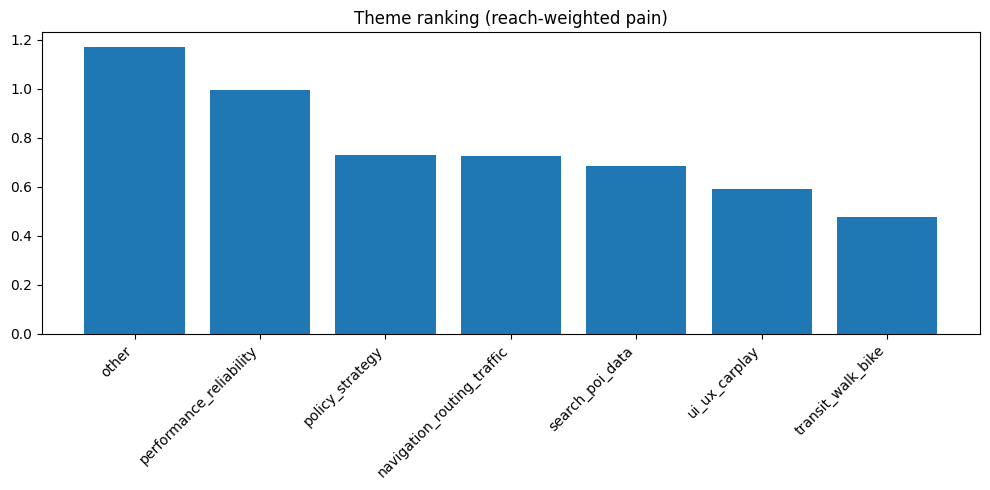

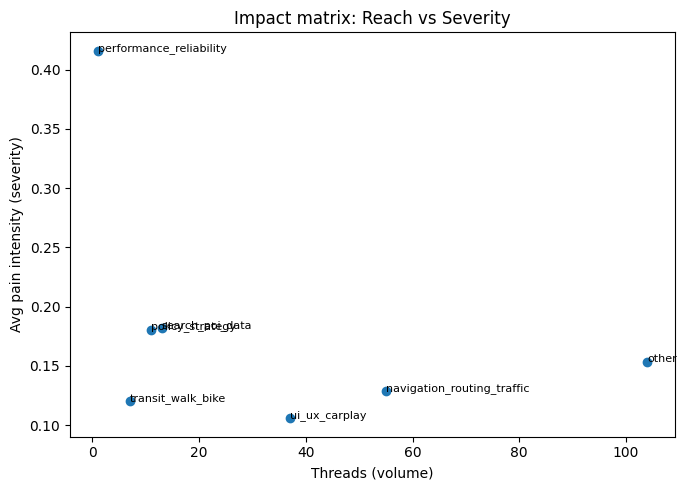

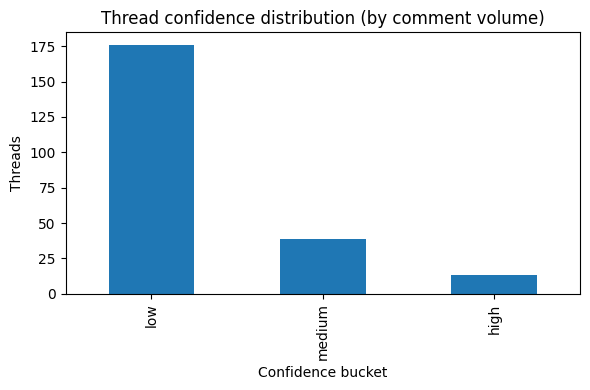

Saved charts to: ../outputs


In [33]:

import matplotlib.pyplot as plt

# 1) Theme ranking by weighted pain (severity * confidence proxy)
# We'll use: avg_pain_intensity * log(1 + total_comments) as a simple reach-weighted score
viz = theme_summary.copy()
viz["reach_weighted_pain"] = viz["avg_pain_intensity"] * (1 + (viz["total_comments"].fillna(0)).apply(lambda x: __import__("math").log1p(x)))

viz_rank = viz.sort_values("reach_weighted_pain", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(viz_rank.index, viz_rank["reach_weighted_pain"])
plt.xticks(rotation=45, ha="right")
plt.title("Theme ranking (reach-weighted pain)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/theme_ranking_reach_weighted_pain.png", dpi=200)
plt.show()

# 2) Impact matrix: reach (threads) vs severity (avg pain)
plt.figure(figsize=(7,5))
plt.scatter(viz["threads"], viz["avg_pain_intensity"])
for theme in viz.index:
    plt.text(viz.loc[theme, "threads"], viz.loc[theme, "avg_pain_intensity"], str(theme), fontsize=8)
plt.xlabel("Threads (volume)")
plt.ylabel("Avg pain intensity (severity)")
plt.title("Impact matrix: Reach vs Severity")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/impact_matrix_reach_vs_severity.png", dpi=200)
plt.show()

# 3) Comment confidence distribution across threads
plt.figure(figsize=(6,4))
df_thread_metrics["comment_confidence"].value_counts().plot(kind="bar")
plt.title("Thread confidence distribution (by comment volume)")
plt.xlabel("Confidence bucket")
plt.ylabel("Threads")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confidence_distribution.png", dpi=200)
plt.show()

print("Saved charts to:", OUTPUT_DIR)


In [34]:
df_thread_metrics.columns

Index(['post_sentiment', 'comment_neg_rate', 'comment_neu_rate',
       'comment_pos_rate', 'n_comments_scraped', 'consensus_strength',
       'pain_intensity', 'theme', 'post_type', 'subreddit', 'url',
       'created_date', 'post_text_clean', 'comment_confidence'],
      dtype='object')

In [35]:
# -------- Post Type Aggregation (Thread-level, like Theme Summary) --------

#df_thread_metrics = thread_metrics_sorted.copy()

post_type_summary = (
    df_thread_metrics.groupby("post_type")
      .agg(
          threads=("pain_intensity", "count"),
          total_comments=("n_comments_scraped", "sum"),
          avg_comments_per_thread=("n_comments_scraped", "mean"),
          avg_pain_intensity=("pain_intensity", "mean"),
          avg_post_sentiment=("post_sentiment", "mean"),
          avg_neg_comment_rate=("comment_neg_rate", "mean"),
          avg_pos_comment_rate=("comment_pos_rate", "mean"),
          avg_consensus=("consensus_strength", "mean"),
      )
      .sort_values(["avg_pain_intensity", "total_comments"], ascending=False)
)

display(post_type_summary)


,threads,total_comments,avg_comments_per_thread,avg_pain_intensity,avg_post_sentiment,avg_neg_comment_rate,avg_pos_comment_rate,avg_consensus
post_type,,,,,,,,
experience_complaint,27,66.0,2.444444,0.205551,0.040089,0.159782,0.174976,0.231244
bug_report,20,21.0,1.050000,0.195459,0.023030,0.133333,0.241667,0.291667
policy_discussion,9,13.0,1.444444,0.187462,-0.049356,0.086111,0.058333,0.027778
other,127,693.0,5.456693,0.127799,0.138816,0.115835,0.203309,0.202558
comparison_discussion,31,139.0,4.483871,0.116548,0.394819,0.088863,0.274255,0.298295
experience_praise,14,70.0,5.000000,0.114249,0.476664,0.076667,0.264762,0.259524


In [36]:
pivot_theme_posttype = (
    df_thread_metrics.pivot_table(
        index="theme",
        columns="post_type",
        values="pain_intensity",
        aggfunc="mean",
        fill_value=0
    )
)

display(pivot_theme_posttype)


post_type,bug_report,comparison_discussion,experience_complaint,experience_praise,other,policy_discussion
theme,,,,,,
navigation_routing_traffic,0.190320,0.158333,0.046130,0.164213,0.121134,0.000000
other,0.200000,0.118374,0.298584,0.084533,0.136472,0.000000
performance_reliability,0.000000,0.000000,0.416000,0.000000,0.000000,0.000000
policy_strategy,0.000000,0.100000,0.000000,0.000000,0.200000,0.187462
search_poi_data,0.328840,0.000000,0.084313,0.319960,0.275075,0.000000
transit_walk_bike,0.103600,0.000000,0.402587,0.000000,0.067490,0.000000
ui_ux_carplay,0.190749,0.103227,0.244060,0.050000,0.073633,0.000000


In [37]:
df_thread_metrics.columns



Index(['post_sentiment', 'comment_neg_rate', 'comment_neu_rate',
       'comment_pos_rate', 'n_comments_scraped', 'consensus_strength',
       'pain_intensity', 'theme', 'post_type', 'subreddit', 'url',
       'created_date', 'post_text_clean', 'comment_confidence'],
      dtype='object')

In [38]:
# -------- Confidence-weighted pain (optional but useful) --------
# Weighted pain down-weights threads with very few comments.
# This helps avoid over-reacting to single-user posts.

CONF_WEIGHTS = {"low": 0.6, "medium": 0.85, "high": 1.0}

# Ensure required columns exist
df_thread_metrics["pain_intensity"] = pd.to_numeric(df_thread_metrics["pain_intensity"], errors="coerce").fillna(0)
df_thread_metrics["comment_confidence"] = df_thread_metrics["comment_confidence"].fillna("low")

df_thread_metrics["weighted_pain"] = df_thread_metrics["pain_intensity"] * df_thread_metrics["comment_confidence"].map(CONF_WEIGHTS).fillna(0.6)
df_thread_metrics[["pain_intensity","comment_confidence","weighted_pain"]].head()


,pain_intensity,comment_confidence,weighted_pain
thread_id,,,
1ofa4am,0.88236,low,0.529416
1nrdnbo,0.79416,low,0.476496
1nkp0lc,0.61168,low,0.367008
1pmkddu,0.60000,low,0.360000
1nqbvtw,0.60000,low,0.360000


In [39]:
# -------- Confidence-aware theme aggregation --------

theme_confidence_summary = (
    df_thread_metrics.groupby("theme")
      .agg(
          threads=("pain_intensity", "count"),
          high_conf_threads=("comment_confidence", lambda x: (x == "high").sum()),
          avg_pain_intensity=("pain_intensity", "mean"),
          avg_weighted_pain=("weighted_pain", "mean"),
          total_comments=("n_comments_scraped", "sum"),
      )
      .sort_values("avg_weighted_pain", ascending=False)
)

display(theme_confidence_summary)


,threads,high_conf_threads,avg_pain_intensity,avg_weighted_pain,total_comments
theme,,,,,
performance_reliability,1,0,0.416000,0.249600,3.0
policy_strategy,11,0,0.180651,0.118845,20.0
other,104,12,0.153646,0.110608,750.0
search_poi_data,13,0,0.181648,0.108989,15.0
transit_walk_bike,7,0,0.120519,0.089751,18.0
navigation_routing_traffic,55,0,0.128937,0.081483,100.0
ui_ux_carplay,37,1,0.105681,0.067498,96.0


In [40]:

# -------- Pain Buckets (Decision-ready labels) --------
# Uses thresholds from CONFIG section for consistency.

def pain_bucket(score: float) -> str:
    if score >= PAIN_CRITICAL_MIN:
        return "critical"
    elif score >= PAIN_HIGH_MIN:
        return "high"
    elif score >= PAIN_MED_MIN:
        return "medium"
    else:
        return "low"

df_thread_metrics["pain_bucket"] = df_thread_metrics["pain_intensity"].apply(pain_bucket)
df_thread_metrics["pain_bucket"].value_counts()


pain_bucket
low         106
medium       53
high         42
critical     27
Name: count, dtype: int64

In [41]:
df_thread_metrics.columns

Index(['post_sentiment', 'comment_neg_rate', 'comment_neu_rate',
       'comment_pos_rate', 'n_comments_scraped', 'consensus_strength',
       'pain_intensity', 'theme', 'post_type', 'subreddit', 'url',
       'created_date', 'post_text_clean', 'comment_confidence',
       'weighted_pain', 'pain_bucket'],
      dtype='object')

In [42]:
# -------- STEP 5A: Top painful threads (overall) --------

top_pain_threads = (
    df_thread_metrics.sort_values("pain_intensity", ascending=False)
      .head(10)
      [[
          "theme",
          "post_type",
          "pain_intensity",
          "comment_confidence",
          "n_comments_scraped",
          "subreddit",
          "created_date",
          "url",
          "post_text_clean"
      ]]
)

display(top_pain_threads)

,theme,post_type,pain_intensity,comment_confidence,n_comments_scraped,subreddit,created_date,url,post_text_clean
thread_id,,,,,,,,,
1ofa4am,search_poi_data,other,0.88236,low,1.0,applemaps,2025-10-24 16:33:50,https://www.reddit.com/r/applemaps/comments/1o...,when does apple maps automatically end a route...
1nrdnbo,other,other,0.79416,low,2.0,applemaps,2025-09-26 16:33:18,https://www.reddit.com/r/applemaps/comments/1n...,scenic route apple maps seriously why would th...
1nkp0lc,other,other,0.61168,low,2.0,applemaps,2025-09-18 19:25:16,https://www.reddit.com/r/applemaps/comments/1n...,"still no n/s/e/w? it's 2025, why can't apple a..."
1pmkddu,other,other,0.60000,low,3.0,applemaps,2025-12-14 11:56:46,https://www.reddit.com/r/applemaps/comments/1p...,jules verne option apple maps added an extra 4...
1nqbvtw,navigation_routing_traffic,comparison_discussion,0.60000,low,1.0,applemaps,2025-09-25 11:46:44,https://www.reddit.com/r/applemaps/comments/1n...,traffico apple maps se apple maps comprasse i ...
1o0kxzu,other,experience_complaint,0.60000,low,1.0,applemaps,2025-10-07 12:16:56,https://www.reddit.com/r/applemaps/comments/1o...,fixing the most annoying apple maps bug — phan...
1p3y8za,other,bug_report,0.60000,low,1.0,applemaps,2025-11-22 11:00:58,https://www.reddit.com/r/applemaps/comments/1p...,a bug in satellite view of apple maps on web [
1p4a75e,navigation_routing_traffic,experience_praise,0.52352,low,2.0,applemaps,2025-11-22 19:38:45,https://www.reddit.com/r/applemaps/comments/1p...,how does apple maps decide routes? i was drivi...
1p579o2,other,other,0.51840,low,3.0,applemaps,2025-11-23 22:07:37,https://www.reddit.com/r/applemaps/comments/1p...,report a incident and native ratings missing i...


In [43]:
# -------- STEP 5B: Top painful threads per theme --------

top_threads_by_theme = (
    df_thread_metrics.sort_values("pain_intensity", ascending=False)
      .groupby("theme")
      .head(3)
      [[
          "theme",
          "post_type",
          "pain_intensity",
          "comment_confidence",
          "n_comments_scraped",
          "url",
          "post_text_clean"
      ]]
)

display(top_threads_by_theme)


,theme,post_type,pain_intensity,comment_confidence,n_comments_scraped,url,post_text_clean
thread_id,,,,,,,
1ofa4am,search_poi_data,other,0.882360,low,1.0,https://www.reddit.com/r/applemaps/comments/1o...,when does apple maps automatically end a route...
1nrdnbo,other,other,0.794160,low,2.0,https://www.reddit.com/r/applemaps/comments/1n...,scenic route apple maps seriously why would th...
1nkp0lc,other,other,0.611680,low,2.0,https://www.reddit.com/r/applemaps/comments/1n...,"still no n/s/e/w? it's 2025, why can't apple a..."
1pmkddu,other,other,0.600000,low,3.0,https://www.reddit.com/r/applemaps/comments/1p...,jules verne option apple maps added an extra 4...
1nqbvtw,navigation_routing_traffic,comparison_discussion,0.600000,low,1.0,https://www.reddit.com/r/applemaps/comments/1n...,traffico apple maps se apple maps comprasse i ...
1p4a75e,navigation_routing_traffic,experience_praise,0.523520,low,2.0,https://www.reddit.com/r/applemaps/comments/1p...,how does apple maps decide routes? i was drivi...
1px4uw4,navigation_routing_traffic,bug_report,0.469880,low,1.0,https://www.reddit.com/r/applemaps/comments/1p...,bugs in apple maps on tahoe? i just tried to p...
1ny1tgl,performance_reliability,experience_complaint,0.416000,low,3.0,https://www.reddit.com/r/applemaps/comments/1n...,apple maps and iphone 13 hello. i use apple ma...
1nizmyv,transit_walk_bike,experience_complaint,0.402587,medium,6.0,https://www.reddit.com/r/applemaps/comments/1n...,apple business connect is awful. can't verify ...


In [44]:
df_thread_metrics

,post_sentiment,comment_neg_rate,comment_neu_rate,comment_pos_rate,n_comments_scraped,consensus_strength,pain_intensity,theme,post_type,subreddit,url,created_date,post_text_clean,comment_confidence,weighted_pain,pain_bucket
thread_id,,,,,,,,,,,,,,,,
1ofa4am,-0.7059,1.0,0.0,0.0,1.0,1.0,0.88236,search_poi_data,other,applemaps,https://www.reddit.com/r/applemaps/comments/1o...,2025-10-24 16:33:50,when does apple maps automatically end a route...,low,0.529416,critical
1nrdnbo,-0.4854,1.0,0.0,0.0,2.0,1.0,0.79416,other,other,applemaps,https://www.reddit.com/r/applemaps/comments/1n...,2025-09-26 16:33:18,scenic route apple maps seriously why would th...,low,0.476496,critical
1nkp0lc,-0.7792,0.5,0.5,0.0,2.0,0.5,0.61168,other,other,applemaps,https://www.reddit.com/r/applemaps/comments/1n...,2025-09-18 19:25:16,"still no n/s/e/w? it's 2025, why can't apple a...",low,0.367008,critical
1pmkddu,0.0000,1.0,0.0,0.0,3.0,1.0,0.60000,other,other,applemaps,https://www.reddit.com/r/applemaps/comments/1p...,2025-12-14 11:56:46,jules verne option apple maps added an extra 4...,low,0.360000,critical
1nqbvtw,0.0000,1.0,0.0,0.0,1.0,1.0,0.60000,navigation_routing_traffic,comparison_discussion,applemaps,https://www.reddit.com/r/applemaps/comments/1n...,2025-09-25 11:46:44,traffico apple maps se apple maps comprasse i ...,low,0.360000,critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1ozailh,0.0000,0.0,0.0,0.0,0.0,0.0,0.00000,other,other,applemaps,https://www.reddit.com/r/applemaps/comments/1o...,2025-11-17 01:56:15,"talking about dense dce in apple maps, check o...",low,0.000000,low
1p01ixl,0.0000,0.0,0.0,0.0,0.0,0.0,0.00000,other,other,applemaps,https://www.reddit.com/r/applemaps/comments/1p...,2025-11-17 21:35:50,apple did make icons for juan manuel fangio st...,low,0.000000,low
1pbsbl5,0.8860,0.0,0.0,0.0,0.0,0.0,0.00000,navigation_routing_traffic,experience_praise,applemaps,https://www.reddit.com/r/applemaps/comments/1p...,2025-12-01 17:23:22,i love the detail in the place names in the ch...,low,0.000000,low


In [45]:
# Convert index to column
df_thread_metrics = df_thread_metrics.reset_index()   # index -> thread_id column

df_thread_metrics.head()




,thread_id,post_sentiment,comment_neg_rate,comment_neu_rate,comment_pos_rate,n_comments_scraped,consensus_strength,pain_intensity,theme,post_type,subreddit,url,created_date,post_text_clean,comment_confidence,weighted_pain,pain_bucket
0,1ofa4am,-0.7059,1.0,0.0,0.0,1.0,1.0,0.88236,search_poi_data,other,applemaps,https://www.reddit.com/r/applemaps/comments/1o...,2025-10-24 16:33:50,when does apple maps automatically end a route...,low,0.529416,critical
1,1nrdnbo,-0.4854,1.0,0.0,0.0,2.0,1.0,0.79416,other,other,applemaps,https://www.reddit.com/r/applemaps/comments/1n...,2025-09-26 16:33:18,scenic route apple maps seriously why would th...,low,0.476496,critical
2,1nkp0lc,-0.7792,0.5,0.5,0.0,2.0,0.5,0.61168,other,other,applemaps,https://www.reddit.com/r/applemaps/comments/1n...,2025-09-18 19:25:16,"still no n/s/e/w? it's 2025, why can't apple a...",low,0.367008,critical
3,1pmkddu,0.0000,1.0,0.0,0.0,3.0,1.0,0.60000,other,other,applemaps,https://www.reddit.com/r/applemaps/comments/1p...,2025-12-14 11:56:46,jules verne option apple maps added an extra 4...,low,0.360000,critical
4,1nqbvtw,0.0000,1.0,0.0,0.0,1.0,1.0,0.60000,navigation_routing_traffic,comparison_discussion,applemaps,https://www.reddit.com/r/applemaps/comments/1n...,2025-09-25 11:46:44,traffico apple maps se apple maps comprasse i ...,low,0.360000,critical


## 8. Evidence Extraction

Pull representative quotes for high-pain threads to make findings human-readable and action-oriented.

In [46]:
# -------- STEP 5C: Representative comments for high-pain threads --------

# -------- STEP 5C+: 2 most negative + 1 most positive comment per high-pain thread --------

if "thread_id" not in df_thread_metrics.columns:
    df_thread_metrics = df_thread_metrics.reset_index()

high_pain_thread_ids = df_thread_metrics.loc[df_thread_metrics["pain_bucket"].isin(["high", "critical"]), "thread_id"].astype(str)

sub = df_sent[
    (df_sent["thread_id"].astype(str).isin(high_pain_thread_ids)) &
    (df_sent["post_or_comment"] == "comment")
].copy()

neg = (sub.sort_values("sentiment_compound")
          .groupby("thread_id", as_index=False)
          .head(2))

pos = (sub.sort_values("sentiment_compound", ascending=False)
          .groupby("thread_id", as_index=False)
          .head(1))

rep_comments_balanced = (
    pd.concat([neg, pos], ignore_index=True)
      .sort_values(["thread_id", "sentiment_compound"])
      [["thread_id", "theme", "post_type", "sentiment_compound", "text_clean"]]
)

display(rep_comments_balanced.head(45))
print("Rows returned:", len(rep_comments_balanced))
print("Unique threads covered:", rep_comments_balanced["thread_id"].nunique())



,thread_id,theme,post_type,sentiment_compound,text_clean
1,1lu5ac6,ui_ux_carplay,experience_complaint,-0.9638,but when will they bring back mini-roundabouts...
28,1lu5ac6,ui_ux_carplay,other,-0.5423,i don’t know why they don’t just make the lock...
111,1lu5ac6,search_poi_data,comparison_discussion,0.8893,i use google maps today but i really want to l...
27,1lvz0k2,other,other,-0.5423,holy fuck
57,1lvz0k2,policy_strategy,policy_discussion,-0.2500,just had to pay a 120 € fine for driving on a ...
124,1lvz0k2,performance_reliability,experience_complaint,0.5994,what a nothing burger article. must be a slow ...
16,1nc31yp,other,experience_complaint,-0.6115,i really hate this apple trend of implementing...
69,1nc31yp,ui_ux_carplay,other,0.0000,"oh, i thought it was a pentagon tour guide"
148,1nc31yp,ui_ux_carplay,other,0.0000,"oh, i thought it was a pentagon tour guide"
37,1nhvktl,other,other,-0.4019,this happens to me all the time. it drives me ...


Rows returned: 164
Unique threads covered: 59



## Executive Summary (shareable)

This section turns the analysis into an “evaluation-style” summary someone can skim in 60 seconds.

**What we did**
- Collected public Reddit threads mentioning Apple Maps (posts + comments) across relevant subreddits.
- Labeled each text snippet with:
  - a **theme** (navigation, UI/CarPlay, POI/search, policy, etc.)
  - a **post type** (complaint, praise, bug, feature request, comparison, policy)
- Computed thread-level metrics to approximate **pain + prioritization**.

**What to look at**
- The **Theme ranking** chart (reach-weighted pain)
- The **Impact matrix** (reach vs severity)
- The **Top high-pain threads** table (with direct URLs)



### Evidence table (export)

To make outreach easy, we export a compact table of:
- high/critical pain threads
- theme + post type
- pain metrics
- URL
- a few representative negative comments (when available)


In [47]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================
# CONFIG: output paths
# =========================
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

THREAD_METRICS_CSV = OUTPUT_DIR / "thread_metrics.csv"
EVIDENCE_CSV = OUTPUT_DIR / "evidence_comments.csv"

# =========================
# 1) Clean df_thread_metrics_out (fix duplicate labels)
# =========================
df_thread_metrics_out = df_thread_metrics.copy()

# If thread_id is index, bring it in; avoid creating duplicates
if df_thread_metrics_out.index.name == "thread_id":
    df_thread_metrics_out = df_thread_metrics_out.reset_index()
elif "thread_id" not in df_thread_metrics_out.columns:
    df_thread_metrics_out = df_thread_metrics_out.reset_index().rename(columns={"index": "thread_id"})

# Drop duplicated column names (keep first occurrence)
df_thread_metrics_out = df_thread_metrics_out.loc[:, ~df_thread_metrics_out.columns.duplicated()].copy()

# Ensure thread_id is clean
if "thread_id" not in df_thread_metrics_out.columns:
    raise KeyError("thread_id not found after cleaning df_thread_metrics_out")

df_thread_metrics_out["thread_id"] = df_thread_metrics_out["thread_id"].astype(str)

# =========================
# 2) Build high_ids (high/critical only)
# =========================
if "pain_bucket" not in df_thread_metrics_out.columns:
    raise KeyError("pain_bucket not found. Run pain bucket cell first.")

high_ids = (
    df_thread_metrics_out.loc[df_thread_metrics_out["pain_bucket"].isin(["high", "critical"]), "thread_id"]
    .astype(str)
    .unique()
    .tolist()
)

print(f"High/Critical threads: {len(high_ids)}")

# =========================
# 3) Representative comments from df_sent (3 most negative per thread)
# =========================
required = {"thread_id", "post_or_comment", "sentiment_compound", "text_clean"}
missing = required - set(df_sent.columns)
if missing:
    raise KeyError(f"df_sent missing required columns: {missing}")

df_sent_tmp = df_sent.copy()
df_sent_tmp["thread_id"] = df_sent_tmp["thread_id"].astype(str)

rep = (
    df_sent_tmp[
        (df_sent_tmp["thread_id"].isin(high_ids)) &
        (df_sent_tmp["post_or_comment"] == "comment") &
        (df_sent_tmp["text_clean"].notna()) &
        (df_sent_tmp["text_clean"].astype(str).str.strip().ne(""))
    ]
    .sort_values("sentiment_compound", ascending=True)   # most negative first
    .groupby("thread_id")
    .head(3)
    .groupby("thread_id")["text_clean"]
    .apply(lambda x: " ||| ".join(x.astype(str).tolist()))
    .rename("representative_comments")
)

# =========================
# 4) Evidence table (thread row + representative comments)
# =========================
wanted_cols = [
    "thread_id", "theme", "post_type", "pain_bucket", "pain_intensity",
    "post_sentiment", "comment_neg_rate", "n_comments_scraped",
    "url", "post_text_clean"
]
existing_cols = [c for c in wanted_cols if c in df_thread_metrics_out.columns]

evidence = (
    df_thread_metrics_out[df_thread_metrics_out["thread_id"].isin(high_ids)][existing_cols]
    .merge(rep.reset_index(), on="thread_id", how="left")
    .sort_values(["pain_intensity", "n_comments_scraped"], ascending=False)
)

# =========================
# 5) Save outputs
# =========================
df_thread_metrics_out.to_csv(THREAD_METRICS_CSV, index=False)
evidence.to_csv(EVIDENCE_CSV, index=False)

print(f"✅ Saved: {THREAD_METRICS_CSV}")
print(f"✅ Saved: {EVIDENCE_CSV}")

display(evidence.head(10))


High/Critical threads: 69
✅ Saved: outputs\thread_metrics.csv
✅ Saved: outputs\evidence_comments.csv


,thread_id,theme,post_type,pain_bucket,pain_intensity,post_sentiment,comment_neg_rate,n_comments_scraped,url,post_text_clean,representative_comments
0,1ofa4am,search_poi_data,other,critical,0.88236,-0.7059,1.000000,1.0,https://www.reddit.com/r/applemaps/comments/1o...,when does apple maps automatically end a route...,explain what you mean by “i’ve adjusted home” ...
1,1nrdnbo,other,other,critical,0.79416,-0.4854,1.000000,2.0,https://www.reddit.com/r/applemaps/comments/1n...,scenic route apple maps seriously why would th...,to avoid severe weather ||| probably bc it avo...
2,1nkp0lc,other,other,critical,0.61168,-0.7792,0.500000,2.0,https://www.reddit.com/r/applemaps/comments/1n...,"still no n/s/e/w? it's 2025, why can't apple a...",maybe do a little google search before a compl...
3,1pmkddu,other,other,critical,0.60000,0.0000,1.000000,3.0,https://www.reddit.com/r/applemaps/comments/1p...,jules verne option apple maps added an extra 4...,i have the same problem sometimes. it´s a bug ...
4,1nqbvtw,navigation_routing_traffic,comparison_discussion,critical,0.60000,0.0000,1.000000,1.0,https://www.reddit.com/r/applemaps/comments/1n...,traffico apple maps se apple maps comprasse i ...,"se mia nonna avesse le ruote, sarebbe una carr..."
5,1o0kxzu,other,experience_complaint,critical,0.60000,0.8677,1.000000,1.0,https://www.reddit.com/r/applemaps/comments/1o...,fixing the most annoying apple maps bug — phan...,hi i have the same problem here so after delet...
6,1p3y8za,other,bug_report,critical,0.60000,0.0000,1.000000,1.0,https://www.reddit.com/r/applemaps/comments/1p...,a bug in satellite view of apple maps on web [,could be a lot of things. some times it is a i...
7,1p4a75e,navigation_routing_traffic,experience_praise,critical,0.52352,-0.5588,0.500000,2.0,https://www.reddit.com/r/applemaps/comments/1p...,how does apple maps decide routes? i was drivi...,keeping in mind that i don’t know where you’re...
8,1p579o2,other,other,critical,0.51840,-0.2960,0.666667,3.0,https://www.reddit.com/r/applemaps/comments/1p...,report a incident and native ratings missing i...,report a incident missing in apple maps in aus...
9,1nhvktl,other,other,critical,0.48396,-0.4599,0.500000,2.0,https://www.reddit.com/r/applemaps/comments/1n...,anyone else have this problem? maybe this is c...,this happens to me all the time. it drives me ...


In [48]:
# =========================
# STEP 1: Top pain threads (decision queue)
# =========================
top_threads = (
    df_thread_metrics_out
    .sort_values(["pain_intensity", "n_comments_scraped"], ascending=False)
    .loc[:, [c for c in [
        "thread_id","theme","post_type","pain_bucket","pain_intensity",
        "n_comments_scraped","comment_neg_rate","comment_pos_rate",
        "post_sentiment","url","post_text_clean"
    ] if c in df_thread_metrics_out.columns]]
    .head(25)
)

display(top_threads)
top_threads.to_csv("outputs/top_pain_threads.csv", index=False)
print("✅ Saved: outputs/top_pain_threads.csv")


,thread_id,theme,post_type,pain_bucket,pain_intensity,n_comments_scraped,comment_neg_rate,comment_pos_rate,post_sentiment,url,post_text_clean
0,1ofa4am,search_poi_data,other,critical,0.882360,1.0,1.000000,0.000000,-0.7059,https://www.reddit.com/r/applemaps/comments/1o...,when does apple maps automatically end a route...
1,1nrdnbo,other,other,critical,0.794160,2.0,1.000000,0.000000,-0.4854,https://www.reddit.com/r/applemaps/comments/1n...,scenic route apple maps seriously why would th...
2,1nkp0lc,other,other,critical,0.611680,2.0,0.500000,0.000000,-0.7792,https://www.reddit.com/r/applemaps/comments/1n...,"still no n/s/e/w? it's 2025, why can't apple a..."
3,1pmkddu,other,other,critical,0.600000,3.0,1.000000,0.000000,0.0000,https://www.reddit.com/r/applemaps/comments/1p...,jules verne option apple maps added an extra 4...
4,1nqbvtw,navigation_routing_traffic,comparison_discussion,critical,0.600000,1.0,1.000000,0.000000,0.0000,https://www.reddit.com/r/applemaps/comments/1n...,traffico apple maps se apple maps comprasse i ...
5,1o0kxzu,other,experience_complaint,critical,0.600000,1.0,1.000000,0.000000,0.8677,https://www.reddit.com/r/applemaps/comments/1o...,fixing the most annoying apple maps bug — phan...
6,1p3y8za,other,bug_report,critical,0.600000,1.0,1.000000,0.000000,0.0000,https://www.reddit.com/r/applemaps/comments/1p...,a bug in satellite view of apple maps on web [
7,1p4a75e,navigation_routing_traffic,experience_praise,critical,0.523520,2.0,0.500000,0.000000,-0.5588,https://www.reddit.com/r/applemaps/comments/1p...,how does apple maps decide routes? i was drivi...
8,1p579o2,other,other,critical,0.518400,3.0,0.666667,0.000000,-0.2960,https://www.reddit.com/r/applemaps/comments/1p...,report a incident and native ratings missing i...
9,1nhvktl,other,other,critical,0.483960,2.0,0.500000,0.000000,-0.4599,https://www.reddit.com/r/applemaps/comments/1n...,anyone else have this problem? maybe this is c...


✅ Saved: outputs/top_pain_threads.csv


In [49]:
# =========================
# STEP 2: Theme ranking (impact overview)
# =========================
theme_rank = (
    df_thread_metrics_out
    .groupby("theme", as_index=False)
    .agg(
        threads=("thread_id", "nunique"),
        total_comments=("n_comments_scraped", "sum"),
        avg_pain=("pain_intensity", "mean"),
        avg_weighted_pain=("weighted_pain", "mean") if "weighted_pain" in df_thread_metrics_out.columns else ("pain_intensity","mean"),
        pct_high_critical=("pain_bucket", lambda s: (s.isin(["high","critical"]).mean()))
    )
    .sort_values(["avg_weighted_pain","threads"], ascending=False)
)

display(theme_rank)
theme_rank.to_csv("outputs/theme_rank.csv", index=False)
print("✅ Saved: outputs/theme_rank.csv")


,theme,threads,total_comments,avg_pain,avg_weighted_pain,pct_high_critical
2,performance_reliability,1,3.0,0.416000,0.249600,1.000000
3,policy_strategy,11,20.0,0.180651,0.118845,0.545455
1,other,104,750.0,0.153646,0.110608,0.269231
4,search_poi_data,13,15.0,0.181648,0.108989,0.384615
5,transit_walk_bike,7,18.0,0.120519,0.089751,0.142857
0,navigation_routing_traffic,55,100.0,0.128937,0.081483,0.309091
6,ui_ux_carplay,37,96.0,0.105681,0.067498,0.297297


✅ Saved: outputs/theme_rank.csv


In [50]:
# =========================
# STEP 3: Evidence pack per theme (quotes you can paste in email/deck)
# =========================
def top_negative_quotes(df, theme, n_threads=5, n_quotes_per_thread=2):
    # pick top threads by pain for the theme
    threads = (
        df[df["theme"] == theme]
        .sort_values(["pain_intensity","n_comments_scraped"], ascending=False)
        .head(n_threads)["thread_id"]
        .astype(str).tolist()
    )
    quotes = (
        df_sent_tmp[
            (df_sent_tmp["thread_id"].isin(threads)) &
            (df_sent_tmp["post_or_comment"] == "comment")
        ]
        .sort_values("sentiment_compound", ascending=True)
        .groupby("thread_id")
        .head(n_quotes_per_thread)
        [["thread_id","sentiment_compound","text_clean"]]
    )
    return quotes

themes = theme_rank["theme"].head(5).tolist()
packs = []

for th in themes:
    q = top_negative_quotes(df_thread_metrics_out, th)
    q["theme"] = th
    packs.append(q)

evidence_pack = pd.concat(packs, ignore_index=True)
display(evidence_pack.head(30))

evidence_pack.to_csv("outputs/evidence_pack_top_themes.csv", index=False)
print("✅ Saved: outputs/evidence_pack_top_themes.csv")


,thread_id,sentiment_compound,text_clean,theme
0,1ny1tgl,-0.4019,i’m iphone 13 user. only had some slow gps pro...,performance_reliability
1,1ny1tgl,0.0000,often indicates an issue with the gps module (...,performance_reliability
2,1p8gdql,-0.6486,"""we've investigated ourselves and found no wro...",policy_strategy
3,1p8gdql,-0.5983,we’ll all know how much full of shit the eu ar...,policy_strategy
4,1nrdnbo,-0.5859,to avoid severe weather,other
5,1nrdnbo,-0.5106,probably bc it avoids the severe weather,other
6,1p3y8za,-0.4039,could be a lot of things. some times it is a i...,other
7,1pmkddu,-0.4019,i have the same problem sometimes. it´s a bug,other
8,1o0kxzu,-0.4019,hi i have the same problem here so after delet...,other
9,1pmkddu,-0.3506,it is weird to have the value rounded to the m...,other


✅ Saved: outputs/evidence_pack_top_themes.csv



### Future work (if iterating)

If we had more time / data, the next upgrades would be:

- **Transformer sentiment** fine-tuned for product feedback (better nuance on sarcasm + mixed sentiment).
- **Aspect-based sentiment** (separate sentiment per feature: routing vs POI vs UI).
- **Causal inference framing** (map feature changes → shifts in pain metrics over time).
- **Geography extraction** (region mentions to find markets with specific pain clusters).
